# Blinkit Data Analytics — Sales performance
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

## 3. Sales performance

### 3.1 Headline figures

In [7]:
q('''
SELECT COUNT(DISTINCT order_id)              AS orders,
       COUNT(DISTINCT customer_id)           AS buying_customers,
       SUM(quantity)                         AS units,
       round(SUM(revenue), 2)                AS revenue,
       round(SUM(revenue) / COUNT(DISTINCT order_id), 2) AS avg_order_value,
       round(SUM(margin_value), 2)           AS gross_margin,
       round(100 * SUM(margin_value) / SUM(revenue), 2)  AS margin_pct,
       round(AVG(rating), 2)                 AS avg_rating
FROM f_sales ''')

,orders,buying_customers,units,revenue,avg_order_value,gross_margin,margin_pct,avg_rating
0,5000,2172,"10,034.00","4,972,415.43",994.48,"1,361,602.88",27.38,3.34


### 3.2 Monthly revenue with month-over-month growth

In [8]:
q('''
WITH m AS (
  SELECT order_month, COUNT(DISTINCT order_id) AS orders, SUM(revenue) AS revenue, SUM(quantity) AS units
  FROM f_sales GROUP BY 1)
SELECT strftime(order_month, '%Y-%m')                 AS month,
       orders, round(revenue, 0) AS revenue, units,
       round(revenue / orders, 0)                      AS aov,
       round(revenue - LAG(revenue) OVER (ORDER BY order_month), 0) AS revenue_change,
       round(100 * (revenue - LAG(revenue) OVER (ORDER BY order_month))
             / NULLIF(LAG(revenue) OVER (ORDER BY order_month), 0), 2) AS mom_growth_pct,
       round(100 * (orders - LAG(orders) OVER (ORDER BY order_month))
             / NULLIF(LAG(orders) OVER (ORDER BY order_month), 0), 2)  AS mom_order_growth_pct
FROM m ORDER BY order_month ''')

,month,orders,revenue,units,aov,revenue_change,mom_growth_pct,mom_order_growth_pct
0,2023-03,120,"110,990.00",227.00,925.00,NaN,NaN,NaN
1,2023-04,238,"249,383.00",483.00,"1,048.00","138,393.00",124.69,98.33
2,2023-05,276,"269,445.00",560.00,976.00,"20,063.00",8.04,15.97
3,2023-06,232,"233,673.00",457.00,"1,007.00","-35,772.00",-13.28,-15.94
4,2023-07,244,"237,061.00",470.00,972.00,"3,388.00",1.45,5.17
5,2023-08,285,"303,512.00",580.00,"1,065.00","66,451.00",28.03,16.80
6,2023-09,262,"277,585.00",537.00,"1,059.00","-25,927.00",-8.54,-8.07
7,2023-10,254,"263,860.00",531.00,"1,039.00","-13,726.00",-4.94,-3.05
8,2023-11,265,"261,475.00",549.00,987.00,"-2,385.00",-0.90,4.33
9,2023-12,268,"253,628.00",524.00,946.00,"-7,846.00",-3.00,1.13


### 3.3 Running revenue and share of total

In [9]:
q('''
WITH m AS (SELECT order_month, SUM(revenue) AS revenue FROM f_sales GROUP BY 1)
SELECT strftime(order_month, '%Y-%m') AS month,
       round(revenue, 0)              AS revenue,
       round(SUM(revenue) OVER (ORDER BY order_month ROWS UNBOUNDED PRECEDING), 0) AS running_revenue,
       round(100 * SUM(revenue) OVER (ORDER BY order_month ROWS UNBOUNDED PRECEDING)
             / SUM(revenue) OVER (), 2) AS running_share_pct,
       round(AVG(revenue) OVER (ORDER BY order_month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 0) AS moving_avg_3m
FROM m ORDER BY order_month ''')

,month,revenue,running_revenue,running_share_pct,moving_avg_3m
0,2023-03,"110,990.00","110,990.00",2.23,"110,990.00"
1,2023-04,"249,383.00","360,372.00",7.25,"180,186.00"
2,2023-05,"269,445.00","629,817.00",12.67,"209,939.00"
3,2023-06,"233,673.00","863,490.00",17.37,"250,834.00"
4,2023-07,"237,061.00","1,100,551.00",22.13,"246,726.00"
5,2023-08,"303,512.00","1,404,063.00",28.24,"258,082.00"
6,2023-09,"277,585.00","1,681,649.00",33.82,"272,719.00"
7,2023-10,"263,860.00","1,945,509.00",39.13,"281,652.00"
8,2023-11,"261,475.00","2,206,983.00",44.38,"267,640.00"
9,2023-12,"253,628.00","2,460,612.00",49.49,"259,654.00"


### 3.4 Revenue by category with contribution and rank

In [10]:
q('''
SELECT category,
       COUNT(DISTINCT order_id)                       AS orders,
       SUM(quantity)                                  AS units,
       round(SUM(revenue), 0)                         AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct,
       RANK() OVER (ORDER BY SUM(revenue) DESC)       AS revenue_rank,
       round(SUM(revenue) / COUNT(DISTINCT order_id), 0) AS aov,
       round(SUM(margin_value), 0)                    AS margin_value,
       RANK() OVER (ORDER BY SUM(margin_value) DESC)  AS margin_rank
FROM f_sales GROUP BY 1 ORDER BY revenue DESC ''')

,category,orders,units,revenue,revenue_share_pct,revenue_rank,aov,margin_value,margin_rank
0,Dairy & Breakfast,566,"1,114.00","639,222.00",12.86,1,"1,129.00","127,844.00",5
1,Pharmacy,481,973.00,"592,369.00",11.91,2,"1,232.00","118,474.00",7
2,Fruits & Vegetables,492,966.00,"559,053.00",11.24,3,"1,136.00","139,763.00",2
3,Pet Care,501,"1,003.00","539,889.00",10.86,4,"1,078.00","188,961.00",1
4,Household Care,509,"1,078.00","444,244.00",8.93,5,873.00,"111,061.00",9
5,Personal Care,454,887.00,"394,895.00",7.94,6,870.00,"138,213.00",3
6,Snacks & Munchies,483,963.00,"394,649.00",7.94,7,817.00,"138,127.00",4
7,Cold Drinks & Juices,375,758.00,"392,718.00",7.90,8,"1,047.00","117,815.00",8
8,Grocery & Staples,449,895.00,"359,938.00",7.24,9,802.00,"53,991.00",11
9,Baby Care,334,655.00,"348,227.00",7.00,10,"1,043.00","104,468.00",10


### 3.5 Top 15 products by revenue

In [11]:
q('''
SELECT DENSE_RANK() OVER (ORDER BY SUM(revenue) DESC) AS rnk,
       product_name, category,
       COUNT(DISTINCT order_id) AS orders, SUM(quantity) AS units,
       round(SUM(revenue), 0)   AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS share_pct
FROM f_sales GROUP BY product_name, category ORDER BY revenue DESC LIMIT 15 ''')

,rnk,product_name,category,orders,units,revenue,share_pct
0,1,Vitamins,Pharmacy,183,380.00,"260,822.00",5.25
1,2,Pet Treats,Pet Care,233,473.00,"252,007.00",5.07
2,3,Cough Syrup,Pharmacy,190,373.00,"203,570.00",4.09
3,4,Toilet Cleaner,Household Care,205,430.00,"199,837.00",4.02
4,5,Bread,Dairy & Breakfast,135,270.00,"184,851.00",3.72
5,6,Dish Soap,Household Care,184,397.00,"184,441.00",3.71
6,7,Cat Food,Pet Care,152,307.00,"166,596.00",3.35
7,8,Baby Wipes,Baby Care,176,328.00,"158,768.00",3.19
8,9,Onions,Fruits & Vegetables,112,222.00,"138,858.00",2.79
9,10,Baby Food,Baby Care,115,236.00,"137,443.00",2.76


### 3.6 Bottom 15 product codes by revenue

In [12]:
q('''
SELECT product_id, any_value(product_name) AS product_name, any_value(category) AS category,
       COUNT(DISTINCT order_id) AS orders, SUM(quantity) AS units, round(SUM(revenue), 0) AS revenue
FROM f_sales GROUP BY product_id ORDER BY revenue ASC LIMIT 15 ''')

,product_id,product_name,category,orders,units,revenue
0,118820,Iced Tea,Cold Drinks & Juices,14,30.00,370.00
1,654297,Potatoes,Fruits & Vegetables,17,36.00,477.00
2,962054,Orange Juice,Cold Drinks & Juices,16,30.00,506.00
3,652118,Frozen Biryani,Instant & Frozen Food,16,34.00,749.00
4,767398,Dish Soap,Household Care,14,34.00,753.00
5,300159,Cola,Cold Drinks & Juices,12,21.00,931.00
6,709916,Detergent,Household Care,15,34.00,"1,148.00"
7,133542,Detergent,Household Care,9,17.00,"1,164.00"
8,473647,Toothpaste,Personal Care,15,30.00,"1,291.00"
9,968887,Dish Soap,Household Care,19,39.00,"1,587.00"


### 3.7 Pareto check on product codes

In [13]:
q('''
WITH p AS (SELECT product_id, SUM(revenue) AS revenue FROM f_sales GROUP BY 1),
r AS (SELECT product_id, revenue,
             ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rn,
             SUM(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) AS cum_rev,
             SUM(revenue) OVER () AS total_rev,
             COUNT(*) OVER () AS total_products FROM p)
SELECT share_of_products || '% of product codes' AS product_group,
       MIN(rn) AS codes_needed,
       round(100 * MAX(cum_rev) / MAX(total_rev), 2) AS revenue_share_pct
FROM (SELECT *, CASE WHEN rn <= 0.1 * total_products THEN 10
                     WHEN rn <= 0.2 * total_products THEN 20
                     WHEN rn <= 0.5 * total_products THEN 50
                     ELSE 100 END AS share_of_products FROM r)
GROUP BY share_of_products ORDER BY share_of_products ''')

,product_group,codes_needed,revenue_share_pct
0,10% of product codes,1,23.11
1,20% of product codes,27,41.49
2,50% of product codes,54,78.68
3,100% of product codes,135,100.00


### 3.8 Number of product codes needed for 50, 70, 80 and 90 percent of revenue

In [14]:
q('''
WITH p AS (SELECT product_id, SUM(revenue) AS revenue FROM f_sales GROUP BY 1),
r AS (SELECT product_id, ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rn,
             100 * SUM(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) / SUM(revenue) OVER () AS cum_pct
      FROM p)
SELECT t AS revenue_target_pct,
       MIN(rn) AS product_codes_needed,
       round(100.0 * MIN(rn) / (SELECT COUNT(*) FROM p), 1) AS pct_of_catalogue
FROM r, (SELECT unnest([50, 70, 80, 90]) AS t)
WHERE cum_pct >= t GROUP BY t ORDER BY t ''')

,revenue_target_pct,product_codes_needed,pct_of_catalogue
0,50,68,25.40
1,70,110,41.00
2,80,139,51.90
3,90,178,66.40


### 3.9 Order value distribution

In [15]:
q('''
SELECT CASE WHEN revenue < 250 THEN 'a. under 250'
            WHEN revenue < 500 THEN 'b. 250-500'
            WHEN revenue < 750 THEN 'c. 500-750'
            WHEN revenue < 1000 THEN 'd. 750-1000'
            WHEN revenue < 1500 THEN 'e. 1000-1500'
            WHEN revenue < 2000 THEN 'f. 1500-2000'
            WHEN revenue < 3000 THEN 'g. 2000-3000'
            ELSE 'h. 3000 and above' END AS order_value_band,
       COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS order_share_pct,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,order_value_band,orders,order_share_pct,revenue,revenue_share_pct
0,a. under 250,792,15.84,"106,401.00",2.14
1,b. 250-500,867,17.34,"322,303.00",6.48
2,c. 500-750,749,14.98,"473,019.00",9.51
3,d. 750-1000,799,15.98,"711,143.00",14.30
4,e. 1000-1500,544,10.88,"677,288.00",13.62
5,f. 1500-2000,626,12.52,"1,102,958.00",22.18
6,g. 2000-3000,623,12.46,"1,579,304.00",31.76


### 3.10 Order value deciles

In [16]:
q('''
WITH d AS (SELECT order_id, revenue, NTILE(10) OVER (ORDER BY revenue) AS decile FROM f_sales)
SELECT decile, COUNT(*) AS orders,
       round(MIN(revenue), 0) AS min_value, round(MAX(revenue), 0) AS max_value,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct
FROM d GROUP BY decile ORDER BY decile ''')

,decile,orders,min_value,max_value,revenue,revenue_share_pct
0,1,500,12.00,163.00,"46,503.00",0.94
1,2,500,163.00,310.00,"117,887.00",2.37
2,3,500,310.00,447.00,"188,500.00",3.79
3,4,500,448.00,632.00,"269,185.00",5.41
4,5,500,632.00,795.00,"351,637.00",7.07
5,6,500,795.00,950.00,"438,121.00",8.81
6,7,500,950.00,"1,263.00","534,378.00",10.75
7,8,500,"1,263.00","1,729.00","748,203.00",15.05
8,9,500,"1,729.00","2,215.00","959,011.00",19.29
9,10,500,"2,215.00","2,988.00","1,318,989.00",26.53


### 3.11 Category revenue by month

In [17]:
q('''
SELECT category,
       round(SUM(revenue) FILTER (WHERE order_month < DATE '2023-10-01'), 0) AS q_2023_early,
       round(SUM(revenue) FILTER (WHERE order_month BETWEEN DATE '2023-10-01' AND DATE '2024-03-01'), 0) AS oct23_mar24,
       round(SUM(revenue) FILTER (WHERE order_month BETWEEN DATE '2024-04-01' AND DATE '2024-11-01'), 0) AS apr24_nov24,
       round(SUM(revenue), 0) AS total_revenue
FROM f_sales GROUP BY category ORDER BY total_revenue DESC ''')

,category,q_2023_early,oct23_mar24,apr24_nov24,total_revenue
0,Dairy & Breakfast,"205,031.00","204,060.00","230,131.00","639,222.00"
1,Pharmacy,"199,007.00","190,253.00","203,109.00","592,369.00"
2,Fruits & Vegetables,"219,171.00","163,251.00","176,630.00","559,053.00"
3,Pet Care,"173,385.00","168,735.00","197,769.00","539,889.00"
4,Household Care,"133,087.00","139,307.00","171,850.00","444,244.00"
5,Personal Care,"141,628.00","118,357.00","134,910.00","394,895.00"
6,Snacks & Munchies,"119,614.00","136,790.00","138,245.00","394,649.00"
7,Cold Drinks & Juices,"155,100.00","106,299.00","131,319.00","392,718.00"
8,Grocery & Staples,"111,870.00","123,621.00","124,447.00","359,938.00"
9,Baby Care,"112,618.00","116,221.00","119,388.00","348,227.00"


### 3.12 Daily revenue outliers

In [18]:
q('''
WITH d AS (SELECT order_date, SUM(revenue) AS revenue, COUNT(*) AS orders FROM f_sales GROUP BY 1),
s AS (SELECT AVG(revenue) AS mu, stddev_samp(revenue) AS sd FROM d)
SELECT order_date, orders, round(revenue, 0) AS revenue,
       round((revenue - mu) / sd, 2) AS z_score
FROM d, s WHERE abs((revenue - mu) / sd) > 2
ORDER BY abs((revenue - mu) / sd) DESC LIMIT 12 ''')

,order_date,orders,revenue,z_score
0,2024-08-27,15,"20,528.00",3.29
1,2023-10-09,14,"19,637.00",3.05
2,2024-10-26,11,"18,552.00",2.76
3,2023-09-09,16,"18,443.00",2.73
4,2023-09-05,13,"18,385.00",2.71
5,2024-01-10,14,"18,234.00",2.67
6,2024-10-15,12,"17,996.00",2.61
7,2023-04-09,11,"17,934.00",2.59
8,2023-08-21,10,"17,905.00",2.59
9,2024-06-21,15,"17,820.00",2.56


## Charts

### 16.1 Monthly revenue and orders

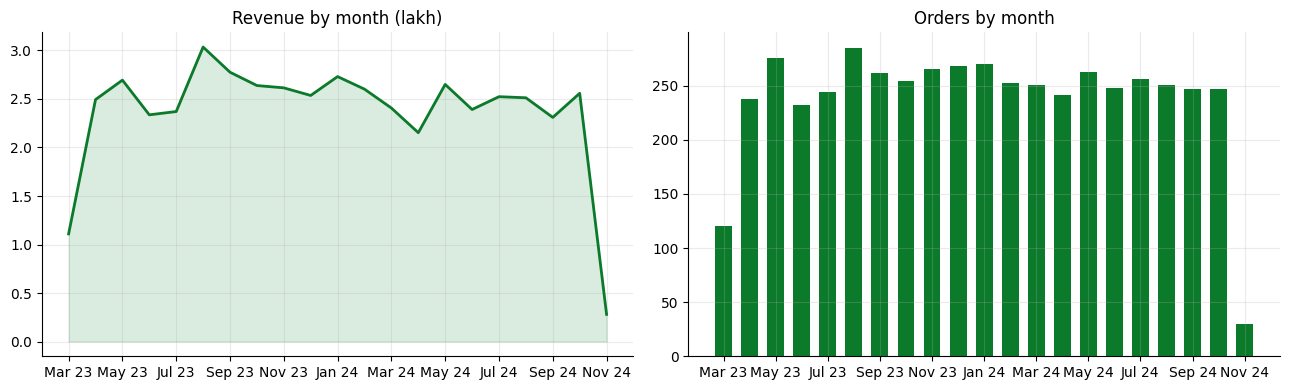

In [19]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'
m = q("SELECT order_month, SUM(revenue) AS revenue, COUNT(DISTINCT order_id) AS orders FROM f_sales GROUP BY 1 ORDER BY 1")
labels = pd.to_datetime(m.order_month).dt.strftime('%b %y')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].fill_between(range(len(m)), m.revenue/1e5, color=GREEN, alpha=.15)
ax[0].plot(range(len(m)), m.revenue/1e5, color=GREEN, lw=2)
ax[0].set_title('Revenue by month (lakh)'); ax[0].set_xticks(range(0, len(m), 2)); ax[0].set_xticklabels(labels[::2], rotation=0)
ax[1].bar(range(len(m)), m.orders, color=GREEN, width=.65)
ax[1].set_title('Orders by month'); ax[1].set_xticks(range(0, len(m), 2)); ax[1].set_xticklabels(labels[::2])
plt.tight_layout(); plt.show()

### 16.2 Revenue concentration curve

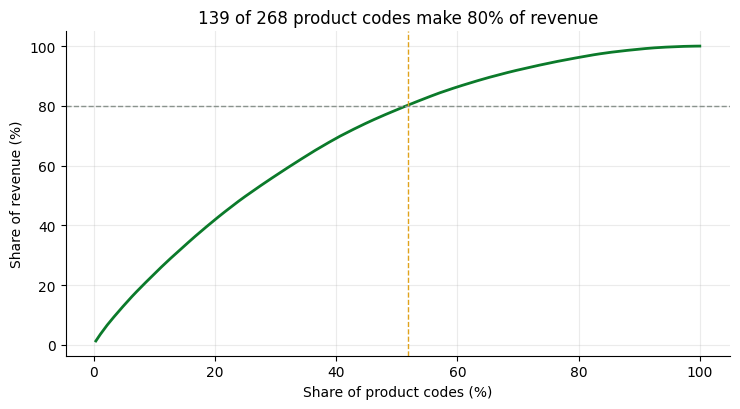

In [20]:
p = q("SELECT product_id, SUM(revenue) AS revenue FROM f_sales GROUP BY 1").sort_values('revenue', ascending=False)
cum = 100 * p.revenue.cumsum() / p.revenue.sum()
x = 100 * np.arange(1, len(p)+1) / len(p)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x, cum, color=GREEN, lw=2)
ax.axhline(80, color=GREY, ls='--', lw=1); ax.axvline(float(x[(cum >= 80).idxmax() if hasattr(cum,'idxmax') else 0]) if False else x[np.argmax(cum.values >= 80)], color=GOLD, ls='--', lw=1)
ax.set_xlabel('Share of product codes (%)'); ax.set_ylabel('Share of revenue (%)')
ax.set_title(f'{np.argmax(cum.values >= 80)+1} of {len(p)} product codes make 80% of revenue')
plt.tight_layout(); plt.show()